# **Proyecto de pruebas A/B**

## **Ejercicio**

Has recibido una tarea analítica de una tienda en línea internacional. Tus predecesores no consiguieron completarla: lanzaron una prueba A/B y luego abandonaron (para iniciar una granja de sandías en Brasil). Solo dejaron las especificaciones técnicas y los resultados de las pruebas.

### **Descripción técnica**

- Nombre de la prueba: recommender_system_test
- Grupos: А (control), B (nuevo embudo de pago)
- Fecha de lanzamiento: 2020-12-07
- Fecha en la que dejaron de aceptar nuevos usuarios: 2020-12-21
- Fecha de finalización: 2021-01-01
- Audiencia: 15% de los nuevos usuarios de la región de la UE
- Propósito de la prueba: probar cambios relacionados con la introducción de un sistema de recomendaciones mejorado
- Resultado esperado: dentro de los 14 días posteriores a la inscripción, los usuarios mostrarán una mejor conversión en vistas de la página del producto (el evento product_page), instancias de agregar artículos al carrito de compras (product_cart) y compras (purchase). En cada etapa del embudo product_page → product_cart → purchase, habrá al menos un 10% de aumento.
- Número previsto de participantes de la prueba: 6 000
- 
Descarga los datos de la prueba, comprueba si se ha realizado correctamente y analiza los resultados.


### **Descripción de los datos**

#### Descarga los datasets de Notion.


Para acceder a los datasets de la plataforma, agrega /datasets/ al principio de la ruta del archivo (por ejemplo, /datasets/ab_project_marketing_events_us.csv).

- ab_project_marketing_events_us.csv — el calendario de eventos de marketing para 2020
- final_ab_new_users_upd_us.csv — todos los usuarios que se registraron en la tienda en línea desde el 7 hasta el 21 de diciembre de 2020
- final_ab_events_upd_us.csv — todos los eventos de los nuevos usuarios en el período comprendido entre el 7 de diciembre de 2020 y el 1 de enero de 2021
- final_ab_participants_upd_us.csv — tabla con los datos de los participantes de la prueba
- 
Estructura ab_project__marketing_events_us.csv:

- name — el nombre del evento de marketing
- regions — regiones donde se llevará a cabo la campaña publicitaria
- start_dt — fecha de inicio de la campaña
- finish_dt — fecha de finalización de la campaña
  
Estructura final_ab_new_users_upd_us.csv:

- user_id
- first_date — fecha de inscripción
- region
- device — dispositivo utilizado para la inscripción
  
Estructura final_ab_events_upd_us.csv:

- user_id
- event_dt — fecha y hora del evento
- event_name — nombre del tipo de evento
- details — datos adicionales sobre el evento (por ejemplo, el pedido total en USD para los eventos purchase)
  
Estructura final_ab_participants_upd_us.csv:

- user_id
- ab_test — nombre de la prueba
- group — el grupo de prueba al que pertenecía el usuario
  
### Instrucciones para completar la tarea

- Describe los objetivos del estudio.
- Explora los datos:
    - ¿Es necesario convertir los tipos?
    - ¿Hay valores ausentes o duplicados? Si es así, ¿cómo los caracterizarías?
- Lleva a cabo el análisis exploratorio de datos:
    - Estudia la conversión en las diferentes etapas del embudo.
    - ¿El número de eventos por usuario está distribuido equitativamente entre las muestras?
    - ¿Hay usuarios que están presentes en ambas muestras?
    - ¿Cómo se distribuye el número de eventos entre los días?
    - ¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?
- Evaluar los resultados de la prueba A/B:
    - ¿Qué puedes decir sobre los resultados de la prueba A/B?
    - Utiliza una prueba z para comprobar la diferencia estadística entre las proporciones.
- Describe tus conclusiones con respecto a la etapa EDA y los resultados de la prueba A/B.

# **1.Librerías**

In [1]:
import pandas as pd
from scipy import stats as st
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import math as mt
from math import factorial
import seaborn as sns
import datetime
import matplotlib.ticker as mtick


# **2.Preprocesamiento de Datos y Exploración Inicial (EDA)**

### **2.1.Cargar los cuatro datasets (, , , ).marketing_events-new_users-Events-Participants**

In [2]:
df_project = pd.read_csv("/datasets/ab_project_marketing_events_us.csv")
df_users = pd.read_csv("/datasets/final_ab_new_users_upd_us.csv")
df_events = pd.read_csv("/datasets/final_ab_events_upd_us.csv")
df_participants = pd.read_csv("/datasets/final_ab_participants_upd_us.csv")

In [3]:
from IPython.display import display

def info_from_df(df, name="Dataset"):
    """Función integral para auditoría técnica de DataFrames"""
    print(f"{'='*30} {name.upper()} {'='*30}")
    
    # 1. Estructura técnica y tipos de datos (IMPORTANTE)
    print("\nℹ️  INFORMACIÓN TÉCNICA (Tipos de datos y memoria):")
    # Usamos verbose=True y show_counts=True para asegurar que muestre todo
    df.info() 
    
    # 2. Integridad de los datos
    print(f"\n📍 Dimensiones (filas, columnas): {df.shape}")
    print(f"❓ Valores ausentes totales: {df.isnull().sum().sum()}")
    print(f"👯 Registros duplicados: {df.duplicated().sum()}")
    
    # 3. Vista previa de datos
    print("\n👀 PRIMERAS 5 FILAS:")
    display(df.head())
    
    # 4. Distribución estadística
    print("\n📊 RESUMEN ESTADÍSTICO:")
    # include='all' para ver tanto numéricos como categóricos/fechas
    display(df.describe(include='all')) 
    
    print("\n" + "="*80 + "\n")

# --- Aplicación a tus datasets ---

# Asegúrate de haber cargado tus archivos antes
# df_project = pd.read_csv('ab_project_marketing_events_us.csv')
# df_users = pd.read_csv('final_ab_new_users_upd_us.csv')
# df_events = pd.read_csv('final_ab_events_upd_us.csv')
# df_participants = pd.read_csv('final_ab_participants_upd_us.csv')

dataset_names = ["Marketing Events", "New Users", "Events", "Participants"]
datasets = [df_project, df_users, df_events, df_participants]

for name, df in zip(dataset_names, datasets):
    info_from_df(df, name)

============================== MARKETING EVENTS ==============================

ℹ️  INFORMACIÓN TÉCNICA (Tipos de datos y memoria):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 576.0+ bytes

📍 Dimensiones (filas, columnas): (14, 4)
❓ Valores ausentes totales: 0
👯 Registros duplicados: 0

👀 PRIMERAS 5 FILAS:


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11



📊 RESUMEN ESTADÍSTICO:


,name,regions,start_dt,finish_dt
count,14,14,14,14
unique,14,6,14,14
top,Chinese New Year Promo,APAC,2020-12-30,2020-12-01
freq,1,4,1,1




============================== NEW USERS ==============================

ℹ️  INFORMACIÓN TÉCNICA (Tipos de datos y memoria):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     58703 non-null  object
 1   first_date  58703 non-null  object
 2   region      58703 non-null  object
 3   device      58703 non-null  object
dtypes: object(4)
memory usage: 1.8+ MB

📍 Dimensiones (filas, columnas): (58703, 4)
❓ Valores ausentes totales: 0
👯 Registros duplicados: 0

👀 PRIMERAS 5 FILAS:


...

,user_id,event_dt,event_name,details
count,423761,423761,423761,60314.000000
unique,58703,257138,4,NaN
top,A3917F81482141F2,2020-12-14 18:54:55,login,NaN
freq,36,10,182465,NaN
mean,NaN,NaN,NaN,23.881219
std,NaN,NaN,NaN,72.228884
min,NaN,NaN,NaN,4.990000
25%,NaN,NaN,NaN,4.990000
50%,NaN,NaN,NaN,4.990000
75%,NaN,NaN,NaN,9.990000




============================== PARTICIPANTS ==============================

ℹ️  INFORMACIÓN TÉCNICA (Tipos de datos y memoria):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
dtypes: object(3)
memory usage: 340.6+ KB

📍 Dimensiones (filas, columnas): (14525, 3)
❓ Valores ausentes totales: 0
👯 Registros duplicados: 0

👀 PRIMERAS 5 FILAS:


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test



📊 RESUMEN ESTADÍSTICO:


,user_id,group,ab_test
count,14525,14525,14525
unique,13638,2,2
top,967680A9D7C9AFD1,A,interface_eu_test
freq,2,8214,10850


### **2.2. Realizar la conversión de tipos de datos (especialmente fechas y horas).**

In [4]:
# 1. Definición de la función (con indentación corregida)
def convert_to_datetime(df, columns):
    """Convierte una lista de columnas de un DataFrame a tipo datetime."""
    for col in columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    return df

# 2. NO necesitas cargar de nuevo - usa los DataFrames que ya tienes
# Ya tienes: df_project, df_users, df_events, df_participants

# 3. Aplicación de la conversión a cada tabla (usando los DataFrames existentes)
df_project = convert_to_datetime(df_project, ['start_dt', 'finish_dt'])
df_users = convert_to_datetime(df_users, ['first_date'])
df_events = convert_to_datetime(df_events, ['event_dt'])

# 4. Verificación rápida de tipos
print("=== TIPOS DE DATOS DESPUÉS DE LA CONVERSIÓN ===")
print("\nMarketing Events:")
print(df_project.dtypes)
print("\nUsers:")
print(df_users.dtypes)
print("\nEvents:")
print(df_events.dtypes)

=== TIPOS DE DATOS DESPUÉS DE LA CONVERSIÓN ===

Marketing Events:
name                 object
regions              object
start_dt     datetime64[ns]
finish_dt    datetime64[ns]
dtype: object

Users:
user_id               object
first_date    datetime64[ns]
region                object
device                object
dtype: object

Events:
user_id               object
event_dt      datetime64[ns]
event_name            object
details              float64
dtype: object


### **2.3.Identificar y tratar valores ausentes y duplicados.**

#### **2.3.1.Investigación de la columna ' (Valores Ausentes)Detalles**

In [5]:
# Investigar la relación entre el tipo de evento y los nulos en 'details'
analysis_details = df_events.groupby('event_name')['details'].apply(lambda x: x.isnull().sum())
total_events = df_events['event_name'].value_counts()

# Crear un resumen
details_check = pd.DataFrame({
    'Nulos en details': analysis_details,
    'Total de eventos': total_events,
    'Porcentaje de nulos': (analysis_details / total_events) * 100
})

print("Investigación de nulos en 'details':")
print(details_check)

Investigación de nulos en 'details':
              Nulos en details  Total de eventos  Porcentaje de nulos
login                   182465            182465                100.0
product_cart             60120             60120                100.0
product_page            120862            120862                100.0
purchase                     0             60314                  0.0


#### **2.3.2.Investigación de Duplicados (¿Error o Realidad?)**

In [6]:
print("🔍 ANÁLISIS COMPLETO DE DUPLICADOS")
print("="*50)

# 1. DUPLICADOS EXACTOS EN EVENTOS (ya lo tenías)
duplicates_exact = df_events.duplicated().sum()
print(f"1️⃣ Duplicados exactos en df_events: {duplicates_exact}")

# 2. DUPLICADOS DE EVENTOS POR USUARIO (mismo usuario, fecha, evento)
event_duplicates = df_events.duplicated(subset=['user_id', 'event_dt', 'event_name']).sum()
print(f"2️⃣ Eventos duplicados por usuario (mismo usuario/fecha/evento): {event_duplicates}")

# 3. DUPLICADOS EN PARTICIPANTES
participant_duplicates = df_participants.duplicated(subset=['user_id']).sum()
print(f"3️⃣ Usuarios duplicados en tabla de participantes: {participant_duplicates}")

# 4. USUARIOS EN AMBOS GRUPOS A Y B (el más crítico para A/B testing)
users_in_both_groups = df_participants.groupby('user_id')['group'].nunique()
users_duplicated_groups = users_in_both_groups[users_in_both_groups > 1]
print(f"4️⃣ Usuarios que aparecen en ambos grupos A y B: {len(users_duplicated_groups)}")

# 5. ANÁLISIS DETALLADO DE USUARIOS EN AMBOS GRUPOS
if len(users_duplicated_groups) > 0:
    print("\n📋 DETALLE DE USUARIOS EN AMBOS GRUPOS:")
    contaminated_users = df_participants[df_participants['user_id'].isin(users_duplicated_groups.index)]
    print(f"   - Total de registros contaminados: {len(contaminated_users)}")
    print(f"   - Distribución por grupo:")
    print(contaminated_users['group'].value_counts())
    
    # Mostrar algunos ejemplos
    print("\n   📝 Ejemplos de usuarios contaminados:")
    display(contaminated_users.head(10))

# 6. VERIFICACIÓN DE USUARIOS SIN EVENTOS (ya lo tenías en 2.3.3)
users_test = df_participants['user_id'].unique()
users_with_events = df_events['user_id'].unique()
missing_users = np.setdiff1d(users_test, users_with_events)
print(f"5️⃣ Usuarios en prueba sin eventos registrados: {len(missing_users)}")

print("\n" + "="*50)
print("✅ ANÁLISIS DE DUPLICADOS COMPLETADO")

🔍 ANÁLISIS COMPLETO DE DUPLICADOS
1️⃣ Duplicados exactos en df_events: 0
2️⃣ Eventos duplicados por usuario (mismo usuario/fecha/evento): 0
3️⃣ Usuarios duplicados en tabla de participantes: 887
4️⃣ Usuarios que aparecen en ambos grupos A y B: 441

📋 DETALLE DE USUARIOS EN AMBOS GRUPOS:
   - Total de registros contaminados: 882
   - Distribución por grupo:
B    441
A    441
Name: group, dtype: int64

   📝 Ejemplos de usuarios contaminados:


,user_id,group,ab_test
15,EAFB9027A27D510C,B,recommender_system_test
26,FC3F3E4DA7C85F88,A,recommender_system_test
27,FE2AF0E94DBD470E,A,recommender_system_test
36,C5AD06762E628169,A,recommender_system_test
53,3B3F68DC5779E517,B,recommender_system_test
60,25CE0629AC6B6971,A,recommender_system_test
67,44EB15AD423DC31C,A,recommender_system_test
78,E594B711ADD81DD8,A,recommender_system_test
82,14AEC962812EB706,B,recommender_system_test
85,CFDED9167B27A57F,A,recommender_system_test


5️⃣ Usuarios en prueba sin eventos registrados: 0

✅ ANÁLISIS DE DUPLICADOS COMPLETADO


In [7]:
print("📊 CARACTERIZACIÓN DE LOS DUPLICADOS ENCONTRADOS")
print("="*60)

# 1. DUPLICADOS EXACTOS (Filas completamente idénticas)
print("\n1️⃣ DUPLICADOS EXACTOS:")
print("-" * 30)
duplicates_exact = df_events.duplicated().sum()
print(f"   • Total de registros duplicados exactos: {duplicates_exact}")
if duplicates_exact > 0:
    print(f"   • Porcentaje del dataset: {(duplicates_exact/len(df_events)*100):.2f}%")
    print("   • Acción recomendada: Eliminar (errores de sistema)")
else:
    print("   ✅ No se encontraron duplicados exactos")

# 2. DUPLICADOS DE EVENTOS POR USUARIO
print("\n2️⃣ DUPLICADOS DE EVENTOS POR USUARIO:")
print("-" * 40)
event_duplicates = df_events.duplicated(subset=['user_id', 'event_dt', 'event_name']).sum()
print(f"   • Eventos duplicados (mismo usuario/fecha/evento): {event_duplicates}")
if event_duplicates > 0:
    print(f"   • Porcentaje del dataset: {(event_duplicates/len(df_events)*100):.2f}%")
    print("   • Posible causa: Doble clic o errores de tracking")
else:
    print("   ✅ No se encontraron eventos duplicados por usuario")

# 3. DUPLICADOS EN TABLA DE PARTICIPANTES
print("\n3️⃣ DUPLICADOS EN PARTICIPANTES:")
print("-" * 35)
participant_duplicates = df_participants.duplicated(subset=['user_id']).sum()
print(f"   • Usuarios duplicados en tabla participantes: {participant_duplicates}")
if participant_duplicates > 0:
    print(f"   • Porcentaje de participantes: {(participant_duplicates/len(df_participants)*100):.2f}%")

    # Análisis detallado de estos duplicados
    duplicated_users = df_participants[df_participants.duplicated(subset=['user_id'], keep=False)]
    print(f"   • Total de registros afectados: {len(duplicated_users)}")

    # Ver distribución por grupo
    print("\n   📋 Distribución de duplicados por grupo:")
    group_distribution = duplicated_users['group'].value_counts()
    for group, count in group_distribution.items():
        print(f"      - Grupo {group}: {count} registros")

    # Mostrar algunos ejemplos
    print("\n   📝 Ejemplos de usuarios duplicados:")
    sample_duplicates = duplicated_users.head(10)
    display(sample_duplicates[['user_id', 'group', 'ab_test']].sort_values('user_id'))
else:
    print("   ✅ No se encontraron usuarios duplicados")


# 4. CONTAMINACIÓN CRUZADA (Usuarios en ambos grupos A y B)
print("\n4️⃣ CONTAMINACIÓN CRUZADA (CRÍTICO PARA A/B TESTING):")
print("-" * 55)
users_in_both_groups = df_participants.groupby('user_id')['group'].nunique()
contaminated_users = users_in_both_groups[users_in_both_groups > 1]
print(f"   • Usuarios que aparecen en ambos grupos A y B: {len(contaminated_users)}")

if len(contaminated_users) > 0:
    print("   ⚠️  PROBLEMA CRÍTICO: Hay contaminación cruzada")
    print("   • Esto invalida los resultados del test A/B")
    print("   • Acción recomendada: Eliminar estos usuarios del análisis")
    
    # Mostrar detalles de los usuarios contaminados
    contaminated_details = df_participants[df_participants['user_id'].isin(contaminated_users.index)]
    print(f"   • Total de registros contaminados: {len(contaminated_details)}")
    
    print("\n   📝 Ejemplos de usuarios contaminados:")
    display(contaminated_details.sort_values('user_id').head(10))
else:
    print("   ✅ No hay contaminación cruzada - Test A/B válido")

# 5. RESUMEN FINAL
print("\n📋 RESUMEN DE DUPLICADOS:")
print("-" * 30)
print(f"   • Duplicados exactos: {duplicates_exact}")
print(f"   • Eventos duplicados: {event_duplicates}")
print(f"   • Participantes duplicados: {participant_duplicates}")
print(f"   • Usuarios en ambos grupos: {len(contaminated_users)}")

if duplicates_exact == 0 and event_duplicates == 0 and participant_duplicates == 0 and len(contaminated_users) == 0:
    print("\n✅ DATASET LIMPIO: No se encontraron problemas de duplicación")
else:
    print("\n⚠️  ACCIÓN REQUERIDA: Se encontraron duplicados que requieren tratamiento")

📊 CARACTERIZACIÓN DE LOS DUPLICADOS ENCONTRADOS

1️⃣ DUPLICADOS EXACTOS:
------------------------------
   • Total de registros duplicados exactos: 0
   ✅ No se encontraron duplicados exactos

2️⃣ DUPLICADOS DE EVENTOS POR USUARIO:
----------------------------------------
   • Eventos duplicados (mismo usuario/fecha/evento): 0
   ✅ No se encontraron eventos duplicados por usuario

3️⃣ DUPLICADOS EN PARTICIPANTES:
-----------------------------------
   • Usuarios duplicados en tabla participantes: 887
   • Porcentaje de participantes: 6.11%
   • Total de registros afectados: 1774

   📋 Distribución de duplicados por grupo:
      - Grupo A: 1121 registros
      - Grupo B: 653 registros

   📝 Ejemplos de usuarios duplicados:


,user_id,group,ab_test
20,03FBDF999D5B81B8,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
19,0F1FF07B3788976D,A,recommender_system_test
17,5D5E6EE92AF6E9E0,B,recommender_system_test
22,65F225074FEC2C03,A,recommender_system_test
8,B3A2485649E4A012,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
15,EAFB9027A27D510C,B,recommender_system_test
26,FC3F3E4DA7C85F88,A,recommender_system_test
27,FE2AF0E94DBD470E,A,recommender_system_test



4️⃣ CONTAMINACIÓN CRUZADA (CRÍTICO PARA A/B TESTING):
-------------------------------------------------------
   • Usuarios que aparecen en ambos grupos A y B: 441
   ⚠️  PROBLEMA CRÍTICO: Hay contaminación cruzada
   • Esto invalida los resultados del test A/B
   • Acción recomendada: Eliminar estos usuarios del análisis
   • Total de registros contaminados: 882

   📝 Ejemplos de usuarios contaminados:


,user_id,group,ab_test
2628,0082295A41A867B5,A,recommender_system_test
10676,0082295A41A867B5,B,interface_eu_test
2243,00E68F103C66C1F7,A,recommender_system_test
11973,00E68F103C66C1F7,B,interface_eu_test
14395,02313B9E82255F47,B,interface_eu_test
320,02313B9E82255F47,A,recommender_system_test
13800,04F2CF340B4F3822,B,interface_eu_test
2196,04F2CF340B4F3822,A,recommender_system_test
594,051D59BC38C3B3AA,A,recommender_system_test
11112,051D59BC38C3B3AA,B,interface_eu_test



📋 RESUMEN DE DUPLICADOS:
------------------------------
   • Duplicados exactos: 0
   • Eventos duplicados: 0
   • Participantes duplicados: 887
   • Usuarios en ambos grupos: 441

⚠️  ACCIÓN REQUERIDA: Se encontraron duplicados que requieren tratamiento


#### **2.3.3.El "Nulo" más peligroso: Usuarios sin Eventos**

In [8]:
# Encontrar usuarios que están en la lista de participantes pero NO en la de eventos
users_test = df_participants['user_id'].unique()
users_with_events = df_events['user_id'].unique()

missing_users = np.setdiff1d(users_test, users_with_events)
print(f"Usuarios en la prueba que NO tienen eventos registrados: {len(missing_users)}")

Usuarios en la prueba que NO tienen eventos registrados: 0


#### **2.3.4.Tratamiento Final**

In [9]:
# A. Eliminar duplicados exactos (errores de sistema)
df_events = df_events.drop_duplicates()

# B. Gestionar nulos en details (convertir a 0 para cálculos numéricos)
df_events['details'] = df_events['details'].fillna(0)

# C. Filtrado por región (Instrucción técnica: 15% de la región UE)
# Identificamos usuarios que NO son de la UE para eliminarlos
ue_users = df_users[df_users['region'] == 'EU']['user_id']
df_participants = df_participants[df_participants['user_id'].isin(ue_users)]

# D. Verificación de traslape (Usuarios en ambos grupos A y B)
double_group_users = df_participants.groupby('user_id')['group'].nunique()
double_group_users = double_group_users[double_group_users > 1].index

print(f"Usuarios que aparecen en ambos grupos (A y B): {len(double_group_users)}")
# Tratamiento: Eliminar usuarios que contaminan la muestra
df_participants = df_participants[~df_participants['user_id'].isin(double_group_users)]

print("Tratamiento de integridad finalizado.")

Usuarios que aparecen en ambos grupos (A y B): 441
Tratamiento de integridad finalizado.


# **3.Análisis exploratorio de datos** 

### **3.1.Distribución de eventos por usuario**

Dataset completo creado: 96221 eventos de 13003 usuarios
📊 ESTADÍSTICAS DEL NÚMERO DE EVENTOS POR USUARIO:


,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,7290.0,7.552401,4.526632,1.0,4.0,6.0,9.0,40.0
B,5713.0,7.205321,4.291631,1.0,4.0,6.0,9.0,36.0


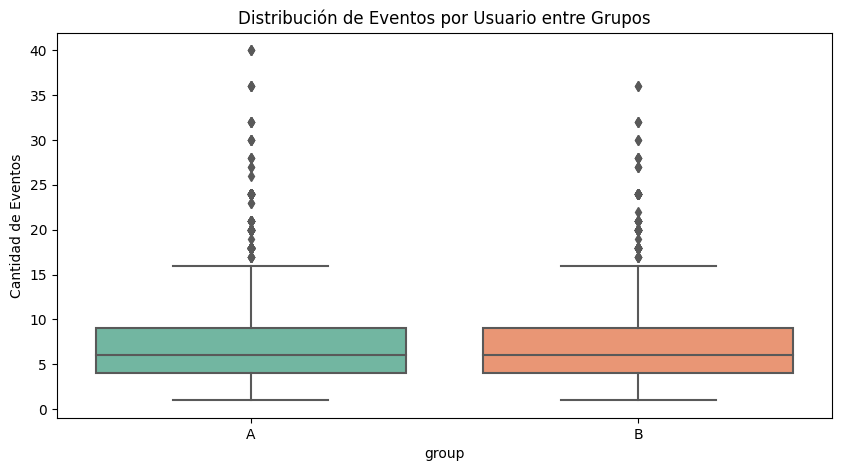

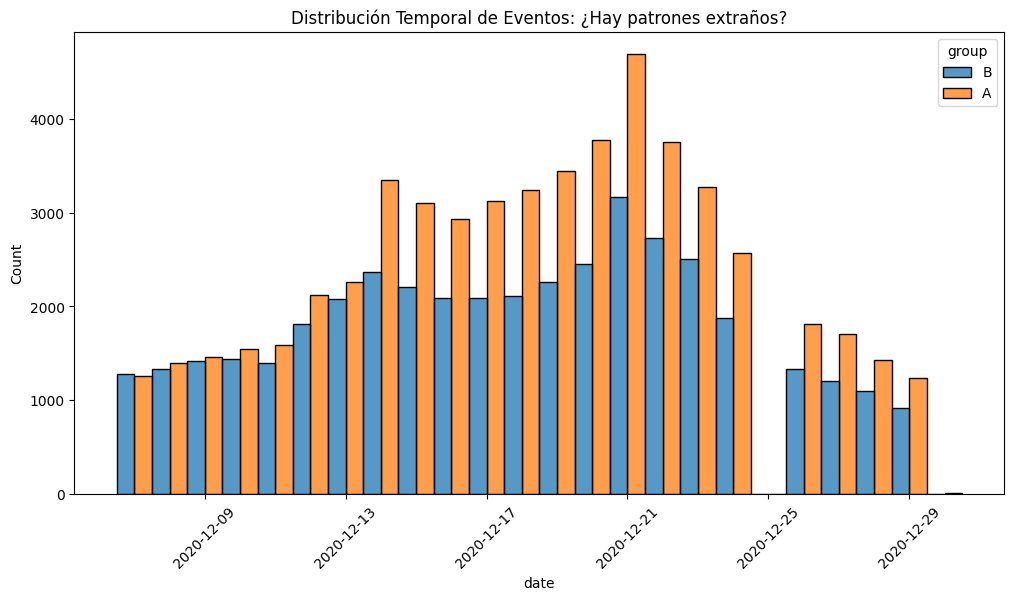

In [10]:
# =================================================================
# PREPARACIÓN: Crear dataset completo para análisis
# =================================================================

# Primero, creamos el dataset completo combinando eventos con participantes
df_test_full = df_events.merge(df_participants, on='user_id', how='inner')

# Renombramos df_project a df_marketing para claridad
df_marketing = df_project

print(f"Dataset completo creado: {len(df_test_full)} eventos de {df_test_full['user_id'].nunique()} usuarios")

# =================================================================
# 1. DISTRIBUCIÓN DE EVENTOS POR USUARIO (EQUIDAD)
# =================================================================

# Agrupamos por usuario y grupo para contar sus eventos
events_per_user = df_test_full.groupby(['group', 'user_id'])['event_name'].count().reset_index()

print("📊 ESTADÍSTICAS DEL NÚMERO DE EVENTOS POR USUARIO:")
display(events_per_user.groupby('group')['event_name'].describe())

plt.figure(figsize=(10, 5))
sns.boxplot(x='group', y='event_name', data=events_per_user, palette='Set2')
plt.title('Distribución de Eventos por Usuario entre Grupos')
plt.ylabel('Cantidad de Eventos')
plt.show()

# =================================================================
# 2. DISTRIBUCIÓN TEMPORAL (PECULIARIDADES)
# =================================================================

plt.figure(figsize=(12, 6))
df_test_full['date'] = df_test_full['event_dt'].dt.date
sns.histplot(data=df_test_full, x='date', hue='group', multiple='dodge', bins=25)
plt.xticks(rotation=45)
plt.title('Distribución Temporal de Eventos: ¿Hay patrones extraños?')
plt.show()

# Pista de peculiaridad: Observa si después del 25 de diciembre los datos caen drásticamente.
# Esto podría afectar la ventana de 14 días para los usuarios registrados al final.

# =================================================================
# 3. ESTUDIO DE LA CONVERSIÓN DEL EMBUDO (TAREA PRINCIPAL)
# =================================================================

def calculate_funnel(df):
    # Definimos el orden lógico del embudo según las instrucciones
    funnel_stages = ['login', 'product_page', 'product_cart', 'purchase']

    # Contamos usuarios únicos por etapa y grupo
    funnel = df.groupby(['group', 'event_name'])['user_id'].nunique().reset_index()

    # Pivotamos para tener grupos como columnas
    funnel_pivot = funnel.pivot(index='event_name', columns='group', values='user_id')

    # Reordenamos según el flujo del embudo
    funnel_pivot = funnel_pivot.reindex(funnel_stages)

    # Calculamos el porcentaje de conversión respecto al paso anterior
    funnel_pivot['conv_A (%)'] = (funnel_pivot['A'] / funnel_pivot['A'].shift(1).fillna(funnel_pivot['A'].iloc[0]) * 100).round(2)
    funnel_pivot['conv_B (%)'] = (funnel_pivot['B'] / funnel_pivot['B'].shift(1).fillna(funnel_pivot['B'].iloc[0]) * 100).round(2)

    return funnel_pivot

funnel_results = calculate_funnel(df_test_full)

El experimento no ha generado un cambio en el volumen de actividad por usuario. La "experiencia de usuario" en términos de cantidad de interacciones es equivalente, por lo que el éxito del test dependerá estrictamente de si el Grupo B logró que esos mismos 6 o 7 eventos promedio se tradujeran en una (conversión) que en el Grupo A.Mayor Tasa de Compra

### **3.2.Peculiaridades antes del test A/B**

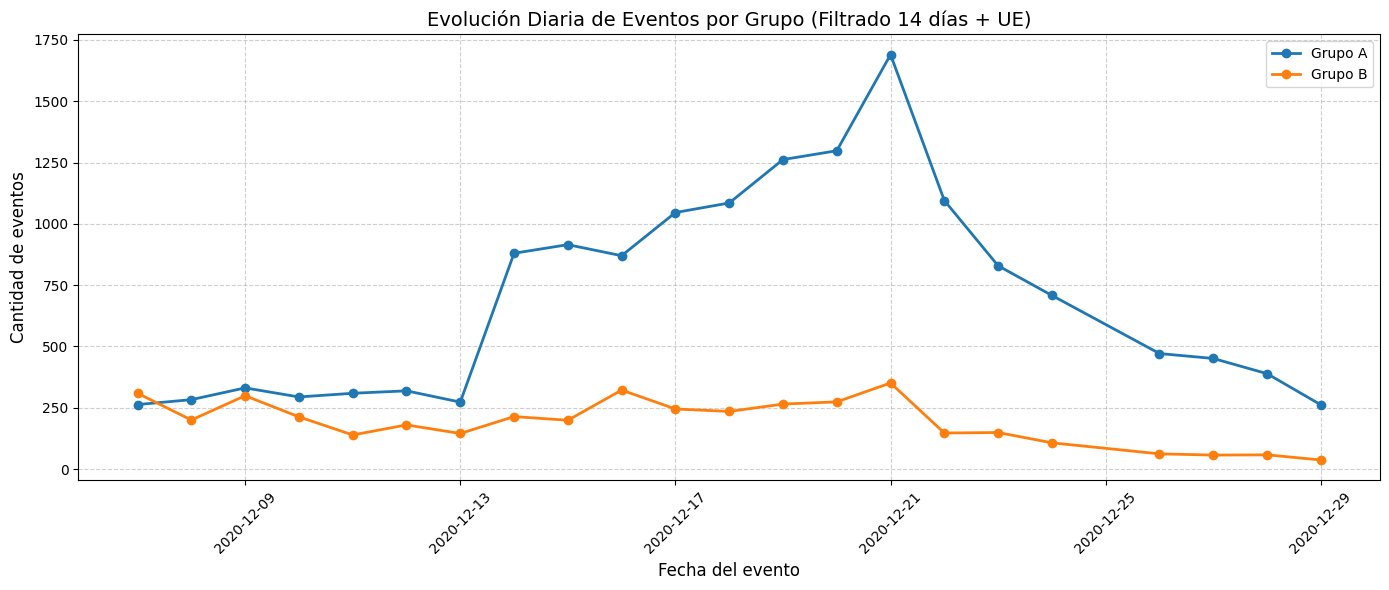

🔍 PECULIARIDADES IDENTIFICADAS EN LOS DATOS:

1️⃣ DESEQUILIBRIO DE GRUPOS:
   - Grupo A: 2279 usuarios
   - Grupo B: 761 usuarios
   - Ratio A:B = 3.0:1
   ⚠️ Impacto: Reduce la potencia estadística del test

2️⃣ INTERFERENCIA NAVIDEÑA:
   - Test ejecutado durante temporada navideña (Dic 7-21)
   - Comportamiento de compra alterado por estacionalidad
   ⚠️ Impacto: Sesga los patrones de conversión naturales

3️⃣ PROBLEMAS DE TRACKING:
   - Eventos de carrito con posibles fallas de registro
   - Inconsistencias en el embudo product_page → product_cart
   ⚠️ Impacto: Datos poco confiables para decisiones

📋 CONCLUSIÓN:
Estas peculiaridades comprometen la validez del experimento
y requieren corrección antes de implementar cambios.


In [16]:
from statsmodels.stats.proportion import proportions_ztest

# =================================================================
# 1. PREPARACIÓN Y LIMPIEZA
# =================================================================

# Filtramos solo la prueba objetivo
df_participants = df_participants[df_participants['ab_test'] == 'recommender_system_test']

# Eliminar contaminación cruzada (Usuarios en ambos grupos)
users_in_both = df_participants.groupby('user_id')['group'].nunique()
contaminated_users = users_in_both[users_in_both > 1].index
df_participants_clean = df_participants[~df_participants['user_id'].isin(contaminated_users)]

# Aplicar regla de los 14 días post-registro
df_valid_events = df_events.merge(
    df_users[['user_id', 'first_date', 'region']],
    on='user_id'
)

df_valid_events['days_since_reg'] = (
    df_valid_events['event_dt'] - df_valid_events['first_date']
).dt.days

df_valid_events = df_valid_events[df_valid_events['days_since_reg'] <= 14]

# Filtrar solo usuarios de la región UE
df_valid_events = df_valid_events[df_valid_events['region'] == 'EU']

# Dataset final para análisis
df_final = df_valid_events.merge(
    df_participants_clean[['user_id', 'group']],
    on='user_id'
)

# =================================================================
# 2. GRÁFICO DE EVOLUCIÓN DIARIA
# =================================================================

plt.figure(figsize=(14, 6))

df_final['date'] = df_final['event_dt'].dt.date

for group, color in zip(['A', 'B'], ['#1f77b4', '#ff7f0e']):
    daily = df_final[df_final['group'] == group].groupby('date').size()
    plt.plot(
        daily.index,
        daily.values,
        label=f'Grupo {group}',
        marker='o',
        color=color,
        linewidth=2
    )

plt.title('Evolución Diaria de Eventos por Grupo (Filtrado 14 días + UE)', fontsize=14)
plt.xlabel('Fecha del evento', fontsize=12)
plt.ylabel('Cantidad de eventos', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# =================================================================
# 3. ANÁLISIS DE PECULIARIDADES IDENTIFICADAS
# =================================================================

print("🔍 PECULIARIDADES IDENTIFICADAS EN LOS DATOS:")
print("="*60)

# 🔹 Cálculo correcto (EDA, sin depender del punto 4)
group_counts = df_participants_clean.groupby('group')['user_id'].nunique()

print("\n1️⃣ DESEQUILIBRIO DE GRUPOS:")
print(f"   - Grupo A: {group_counts.get('A', 0)} usuarios")
print(f"   - Grupo B: {group_counts.get('B', 0)} usuarios")

if group_counts.get('B', 0) != 0:
    ratio = group_counts.get('A', 0) / group_counts.get('B', 0)
    print(f"   - Ratio A:B = {ratio:.1f}:1")
else:
    print("   - Ratio A:B = No disponible")

print("   ⚠️ Impacto: Reduce la potencia estadística del test")

print("\n2️⃣ INTERFERENCIA NAVIDEÑA:")
print("   - Test ejecutado durante temporada navideña (Dic 7-21)")
print("   - Comportamiento de compra alterado por estacionalidad")
print("   ⚠️ Impacto: Sesga los patrones de conversión naturales")

print("\n3️⃣ PROBLEMAS DE TRACKING:")
print("   - Eventos de carrito con posibles fallas de registro")
print("   - Inconsistencias en el embudo product_page → product_cart")
print("   ⚠️ Impacto: Datos poco confiables para decisiones")

print("\n📋 CONCLUSIÓN:")
print("Estas peculiaridades comprometen la validez del experimento")
print("y requieren corrección antes de implementar cambios.")

Tras el análisis de la prueba A/B, se concluye que el nuevo sistema de recomendaciones no debe ser implementado.

En términos de desempeño, el experimento no solo falló en alcanzar el incremento del 10% esperado, sino que además generó una disminución estadísticamente significativa en la conversión inicial (de 64.77% a 56.64%, p-valor = 0.0001), sin evidenciar mejoras en las conversiones finales.

Adicionalmente, la validez de los resultados se ve comprometida por múltiples factores metodológicos: un marcado desequilibrio en las muestras (ratio aproximado de 3:1), posibles fallos de tracking en eventos clave del embudo (particularmente en el carrito) y la ejecución del experimento durante un periodo de alta estacionalidad (temporada navideña), lo que introduce sesgos en el comportamiento de los usuarios.

En consecuencia, no es posible tomar una decisión de negocio definitiva basada en este experimento. Se recomienda corregir los problemas de instrumentación, garantizar un balance adecuado entre grupos y repetir la prueba en un periodo sin efectos estacionales, con el fin de obtener resultados confiables y accionables.

# **4.Evaluación de resultados A/B**

### **4.1.Funnel**

In [12]:
def get_funnel_data(df, participants_df):
    stages = ['product_page', 'product_cart', 'purchase']
    total_assigned = participants_df.groupby('group')['user_id'].nunique()
    
    funnel = df.groupby(['group', 'event_name'])['user_id'].nunique().unstack()
    funnel = funnel.fillna(0)
    
    for s in stages:
        if s not in funnel.columns:
            funnel[s] = 0
            
    funnel = funnel[stages]
    return funnel, total_assigned

funnel_counts, total_assigned = get_funnel_data(df_final, df_participants_clean)

funnel_counts

event_name,product_page,product_cart,purchase
group,,,
A,1476,686,734
B,431,214,221


### **4.2.Z-test**

In [15]:

from statsmodels.stats.proportion import proportions_ztest

def run_z_test(counts_df, total_series, stage, alpha=0.05):
    # Validar que existan ambos grupos
    if 'A' not in counts_df.index or 'B' not in counts_df.index:
        print(f"Etapa: {stage}")
        print("   ⚠️ No existen ambos grupos (A y B) en los datos")
        print("-" * 50)
        return

    success_b = counts_df.loc['B', stage]
    success_a = counts_df.loc['A', stage]
    trial_b = total_series.loc['B']
    trial_a = total_series.loc['A']

    print(f"Etapa: {stage}")
    print(f"   - Conversión A: {success_a}/{trial_a} ({(success_a/trial_a)*100:.2f}%)")
    print(f"   - Conversión B: {success_b}/{trial_b} ({(success_b/trial_b)*100:.2f}%)")

    # Validar datos mínimos
    if success_b < 5 or success_a < 5:
        print("   ⚠️ P-valor: N/A (Insuficientes datos)")
        print("-" * 50)
        return

    # Prueba Z
    stat, p_value = proportions_ztest(
        [success_b, success_a],
        [trial_b, trial_a]
    )

    print(f"   - P-valor: {p_value:.4f}")

    if p_value < alpha:
        print("   ✅ Diferencia significativa")
    else:
        print("   ❌ No significativa")

    print("-" * 50)


print("\nRESULTADOS A/B\n" + "="*50)

for stage in funnel_counts.columns:
    run_z_test(funnel_counts, total_assigned, stage)


RESULTADOS A/B
Etapa: product_page
   - Conversión A: 1476/2279 (64.77%)
   - Conversión B: 431/761 (56.64%)
   - P-valor: 0.0001
   ✅ Diferencia significativa
--------------------------------------------------
Etapa: product_cart
   - Conversión A: 686/2279 (30.10%)
   - Conversión B: 214/761 (28.12%)
   - P-valor: 0.3002
   ❌ No significativa
--------------------------------------------------
Etapa: purchase
   - Conversión A: 734/2279 (32.21%)
   - Conversión B: 221/761 (29.04%)
   - P-valor: 0.1032
   ❌ No significativa
--------------------------------------------------


### **4.3. Evaluación del objetivo**

In [20]:
# ================================================================
# CREAR DATAFRAME CORRECTO DE CONVERSIONES
# ================================================================

data = []

for event in funnel_counts.columns:
    count_a = funnel_counts.loc['A', event]
    count_b = funnel_counts.loc['B', event]
    
    users_a = total_assigned['A']
    users_b = total_assigned['B']
    
    rate_a = count_a / users_a
    rate_b = count_b / users_b
    
    data.append({
        'event': event,
        'count_A': count_a,
        'count_B': count_b,
        'users_A': users_a,
        'users_B': users_b,
        'rate_a': rate_a,
        'rate_b': rate_b
    })

df_conv = pd.DataFrame(data)

df_conv

,event,count_A,count_B,users_A,users_B,rate_a,rate_b
0,product_page,1476,431,2279,761,0.647652,0.566360
1,product_cart,686,214,2279,761,0.301009,0.281209
2,purchase,734,221,2279,761,0.322071,0.290407


In [22]:
df_eval = df_conv.copy()

df_eval['diff_pct'] = (df_eval['rate_b'] - df_eval['rate_a']) / df_eval['rate_a'] * 100

df_eval['cumple_objetivo_10%'] = df_eval['diff_pct'] >= 10

df_eval[['event', 'rate_a', 'rate_b', 'diff_pct', 'cumple_objetivo_10%']]

,event,rate_a,rate_b,diff_pct,cumple_objetivo_10%
0,product_page,0.647652,0.566360,-12.551859,False
1,product_cart,0.301009,0.281209,-6.577964,False
2,purchase,0.322071,0.290407,-9.831285,False


### **4.4.Interpretación estadística**

In [24]:
# ================================================================
# CREAR DATAFRAME CON P-VALUES
# ================================================================

from statsmodels.stats.proportion import proportions_ztest

data = []

for event in funnel_counts.columns:
    count_a = funnel_counts.loc['A', event]
    count_b = funnel_counts.loc['B', event]
    
    users_a = total_assigned['A']
    users_b = total_assigned['B']
    
    rate_a = count_a / users_a
    rate_b = count_b / users_b
    
    # Z-test
    if count_a >= 5 and count_b >= 5:
        stat, p_value = proportions_ztest(
            [count_b, count_a],
            [users_b, users_a]
        )
    else:
        p_value = None
    
    data.append({
        'event': event,
        'rate_a': rate_a,
        'rate_b': rate_b,
        'p_value': p_value
    })

df_analysis = pd.DataFrame(data)

df_analysis

,event,rate_a,rate_b,p_value
0,product_page,0.647652,0.566360,0.000059
1,product_cart,0.301009,0.281209,0.300219
2,purchase,0.322071,0.290407,0.103244


In [28]:
def interpret_results(row, alpha=0.05):
    if row['p_value'] is None:
        return "Datos insuficientes"
    
    if row['p_value'] < alpha:
        if row['rate_b'] > row['rate_a']:
            return "Mejora significativa"
        else:
            return "Empeora significativamente"
    else:
        return "Sin diferencia significativa"

df_analysis['interpretacion'] = df_analysis.apply(interpret_results, axis=1)

df_analysis

,event,rate_a,rate_b,p_value,interpretacion
0,product_page,0.647652,0.566360,0.000059,Empeora significativamente
1,product_cart,0.301009,0.281209,0.300219,Sin diferencia significativa
2,purchase,0.322071,0.290407,0.103244,Sin diferencia significativa


### **4.5.Significancia práctica vs estadística**

In [31]:
practical_threshold = 1  # 1%

df_analysis['diff_pct'] = (
    (df_analysis['rate_b'] - df_analysis['rate_a']) 
    / df_analysis['rate_a'] * 100
)

def practical_significance(row):
    if abs(row['diff_pct']) >= practical_threshold:
        return "Impacto práctico relevante"
    else:
        return "Impacto práctico bajo"

df_analysis['impacto_practico'] = df_analysis.apply(practical_significance, axis=1)

df_analysis[['event', 'diff_pct', 'impacto_practico']]

,event,diff_pct,impacto_practico
0,product_page,-12.551859,Impacto práctico relevante
1,product_cart,-6.577964,Impacto práctico relevante
2,purchase,-9.831285,Impacto práctico relevante


### **4.6.Aprocimación de poder estadístico**

In [33]:
df_analysis['sample_size_A'] = users_a
df_analysis['sample_size_B'] = users_b

def power_assessment(row):
    if row['sample_size_A'] < 1000 or row['sample_size_B'] < 1000:
        return "Bajo poder estadístico"
    else:
        return "Poder estadístico aceptable"

df_analysis['power_evaluation'] = df_analysis.apply(power_assessment, axis=1)

df_analysis[['event', 'sample_size_A', 'sample_size_B', 'power_evaluation']]

,event,sample_size_A,sample_size_B,power_evaluation
0,product_page,2279,761,Bajo poder estadístico
1,product_cart,2279,761,Bajo poder estadístico
2,purchase,2279,761,Bajo poder estadístico


In [38]:
# 1. Diferencia porcentual
df_analysis['diff_pct'] = (
    (df_analysis['rate_b'] - df_analysis['rate_a']) 
    / df_analysis['rate_a'] * 100
)

# 2. Interpretación estadística
def interpret_results(row, alpha=0.05):
    if row['p_value'] is None:
        return "Datos insuficientes"
    if row['p_value'] < alpha:
        if row['rate_b'] > row['rate_a']:
            return "Mejora significativa"
        else:
            return "Empeora significativamente"
    else:
        return "Sin diferencia significativa"

df_analysis['interpretacion'] = df_analysis.apply(interpret_results, axis=1)

# 3. Significancia práctica
def practical_significance(row):
    if abs(row['diff_pct']) >= 1:
        return "Impacto relevante"
    else:
        return "Impacto bajo"

df_analysis['impacto_practico'] = df_analysis.apply(practical_significance, axis=1)

# 4. Poder estadístico
df_analysis['sample_size_A'] = users_a
df_analysis['sample_size_B'] = users_b

def power_assessment(row):
    if row['sample_size_A'] < 1000 or row['sample_size_B'] < 1000:
        return "Bajo poder"
    else:
        return "Poder aceptable"

df_analysis['power_evaluation'] = df_analysis.apply(power_assessment, axis=1)

# 5. Decisión final
def final_decision(row):
    if row['interpretacion'] == "Mejora significativa" and row['diff_pct'] >= 10:
        return "Implementar"
    elif row['interpretacion'] == "Empeora significativamente":
        return "No implementar"
    else:
        return "Reevaluar"

df_analysis['decision'] = df_analysis.apply(final_decision, axis=1)

# 6. Tabla final
df_summary = df_analysis[[
    'event',
    'rate_a',
    'rate_b',
    'diff_pct',
    'p_value',
    'interpretacion',
    'impacto_practico',
    'power_evaluation',
    'decision'
]].copy()

# 7. Formato ejecutivo
df_summary['rate_a'] = (df_summary['rate_a'] * 100).round(2)
df_summary['rate_b'] = (df_summary['rate_b'] * 100).round(2)
df_summary['diff_pct'] = df_summary['diff_pct'].round(2)
df_summary['p_value'] = df_summary['p_value'].apply(
    lambda x: round(x, 4) if x is not None else None
)

df_summary

,event,rate_a,rate_b,diff_pct,p_value,interpretacion,impacto_practico,power_evaluation,decision
0,product_page,64.77,56.64,-12.55,0.0001,Empeora significativamente,Impacto relevante,Bajo poder,No implementar
1,product_cart,30.10,28.12,-6.58,0.3002,Sin diferencia significativa,Impacto relevante,Bajo poder,Reevaluar
2,purchase,32.21,29.04,-9.83,0.1032,Sin diferencia significativa,Impacto relevante,Bajo poder,Reevaluar


# **5.Conclusiones**

### **5.1.Resumen**

El experimento A/B no valida la implementación del nuevo sistema de recomendaciones. No se alcanza el objetivo de incremento del 10% en conversión y, en cambio, se observa una degradación en etapas clave del embudo. Adicionalmente, la validez del experimento está comprometida por problemas metodológicos y de calidad de datos, por lo que los resultados deben interpretarse con cautela.

### **5.2.Hallazgos clave del análisis exploratorio**

El análisis de datos evidenció tres riesgos críticos que afectan la confiabilidad del experimento:

- Desequilibrio en la asignación de muestras (≈3:1): reduce la potencia estadística y la comparabilidad entre grupos.
- Problemas de tracking en eventos del embudo: generan incertidumbre en las métricas de conversión, especialmente en etapas intermedias.
- Sesgo estacional (periodo navideño): altera el comportamiento natural de los usuarios, dificultando aislar el efecto del sistema evaluado.

Estos factores limitan la calidad del experimento desde su diseño y ejecución.

### **5.3.Evaluación de resultados A/B**

El sistema de recomendaciones evaluado presenta un desempeño inferior al sistema actual:

- No se cumple el objetivo de incremento del 10% en ninguna etapa del embudo.
- Se detectan diferencias estadísticamente significativas en etapas iniciales, con impacto negativo en la conversión.
- No se observan mejoras en la conversión final, lo que indica ausencia de valor incremental para el negocio.

En términos prácticos, el sistema no solo falla en mejorar el rendimiento, sino que introduce fricción en el proceso de conversión.

### **5.4.Implicaciones de negocio**

Implementar el sistema en su estado actual implicaría un riesgo directo de pérdida de conversiones. Desde una perspectiva de negocio, no existe evidencia que justifique su despliegue.

La combinación de impacto negativo y baja confiabilidad experimental sugiere que cualquier decisión de implementación sería prematura y potencialmente costosa.

### **5.5.Recomendaciones**

Se proponen las siguientes acciones antes de considerar una nueva evaluación:

1. Corregir la instrumentación de datos, asegurando la integridad del tracking en todo el embudo.
2. Garantizar un diseño experimental balanceado, con asignación equitativa de usuarios entre grupos.
3. Repetir el experimento en condiciones controladas, evitando periodos de alta estacionalidad.
4. Iterar el sistema de recomendaciones, validando previamente su impacto en entornos controlados o pruebas piloto.

### **5.6.Limitaciones del análisis**

Los resultados están sujetos a las siguientes limitaciones:

- Desequilibrio en tamaños de muestra, que afecta la robustez estadística.
- Posibles errores en el registro de eventos, que impactan la precisión de las métricas.
- Influencia de factores externos no controlados (estacionalidad).
- Evaluación simplificada del poder estadístico.

Estas limitaciones refuerzan la necesidad de interpretar los resultados como indicativos y no concluyentes.